## Task 16: Assignment


Q1. Load the insurance dataset using pandas and display the first 10 rows of the data.



In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the insurance dataset
df = pd.read_csv("insurance.csv")

In [3]:
# Display the first 10 rows
df.head(10)

,age,sex,bmi,children,smoker,region
0,19,female,27.9,0.0,yes,southwest
1,18,male,33.8,1.0,no,southeast
2,28,male,33.0,3.0,no,southeast
3,33,male,22.7,0.0,no,northwest
4,32,male,28.9,0.0,no,northwest
5,31,female,25.7,0.0,no,southeast
6,46,female,33.4,1.0,no,southeast
7,37,female,27.7,3.0,no,northwest
8,37,male,29.8,2.0,no,northeast
9,60,female,25.8,0.0,no,northwest


Q2. Use pandas functions to get basic information about the dataset:
   


In [7]:
# Shape of the data
print("Shape of the dataset (Rows, Columns):")
print(df.shape)

Shape of the dataset (Rows, Columns):
(2677, 6)


In [8]:
# Column names, data types, and non-null counts
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2677 entries, 0 to 2676
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2677 non-null   object 
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   float64
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
dtypes: float64(2), object(4)
memory usage: 125.6+ KB


In [9]:
# Statistical summary of numerical columns
print("Statistical Summary:")
df.describe()

Statistical Summary:


,bmi,children
count,1338.000000,1338.000000
mean,30.665471,1.094918
std,6.098382,1.205493
min,16.000000,0.000000
25%,26.300000,0.000000
50%,30.400000,1.000000
75%,34.700000,2.000000
max,53.100000,5.000000


Q3. Check if the dataset contains any null/missing values. Show the count of null
values for each column.


In [10]:
df.isnull().sum()

age            0
sex         1339
bmi         1339
children    1339
smoker      1339
region      1339
dtype: int64

Q4. Identify numerical and categorical columns in the dataset. Print them
separately.


In [13]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Print them separately
print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['bmi', 'children']

Categorical Columns:
['age', 'sex', 'smoker', 'region']


Q5. Create distribution plots for all numerical columns (age, bmi, children,
charges):

Use sns.histplot() or sns.distplot()

Create one plot per column (total 4 plots)

Add meaningful titles and labels

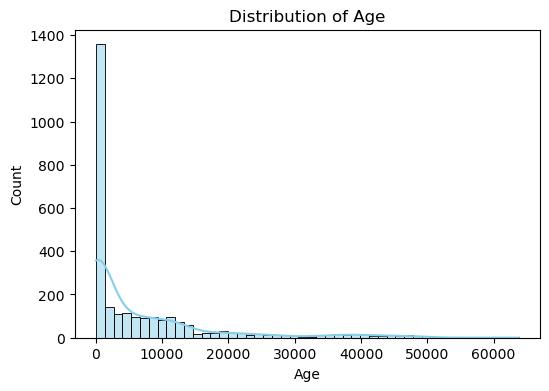

In [17]:
#  Convert 'age' column to numeric values 
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Plot: Age Distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['age'], kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


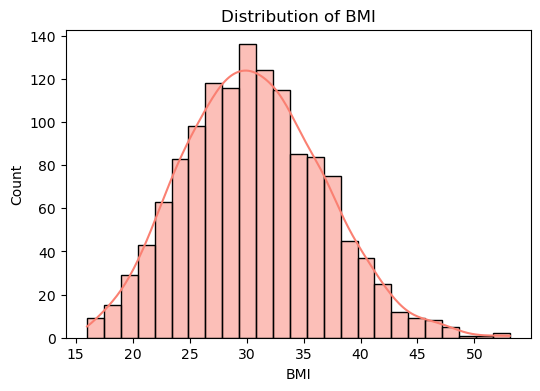

In [18]:
# Plot: BMI Distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['bmi'], kde=True, color='salmon')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.show()

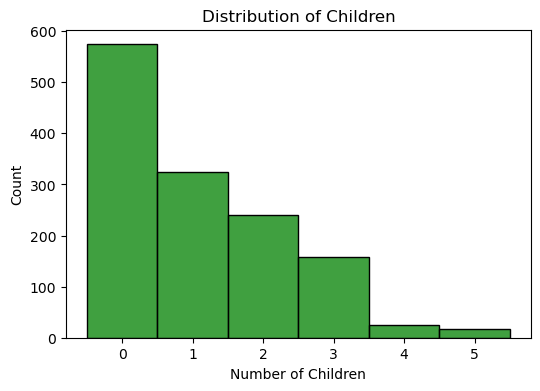

In [19]:
# Plot: Children Distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['children'], kde=False, color='green', discrete=True)
plt.title('Distribution of Children')
plt.xlabel('Number of Children')
plt.ylabel('Count')
plt.show()

Q6. Create count plots for all categorical columns (sex, smoker, region):

Use sns.countplot() for each column

Add titles and labels for clarity


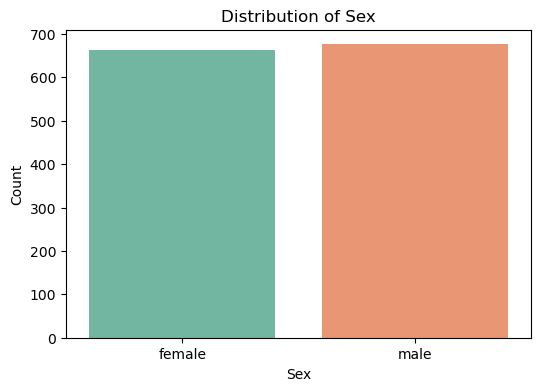

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count plot for 'sex'
plt.figure(figsize=(6, 4))
sns.countplot(x='sex', data=df, hue='sex', palette='Set2', legend=False)
plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

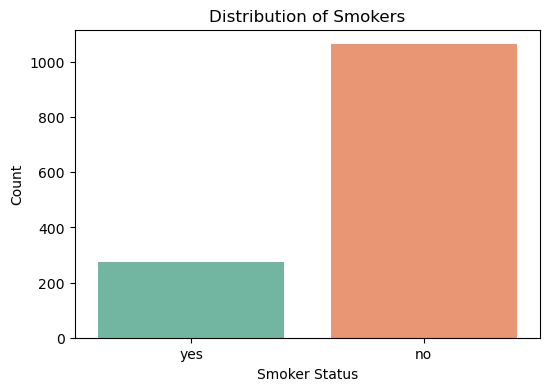

In [21]:
# Count plot for 'smoker'
plt.figure(figsize=(6, 4))
sns.countplot(x='smoker', data=df, hue='smoker', palette='Set2', legend=False)
plt.title('Distribution of Smokers')
plt.xlabel('Smoker Status')
plt.ylabel('Count')
plt.show()

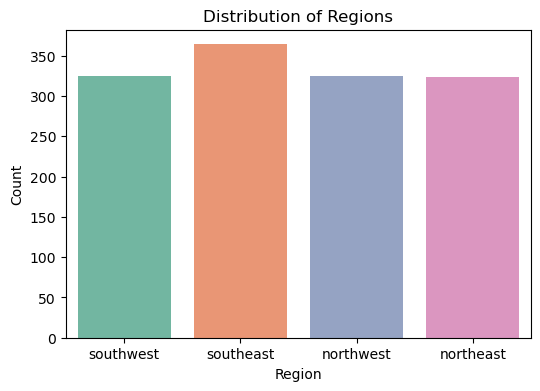

In [22]:
# Count plot for 'region'
plt.figure(figsize=(6, 4))
sns.countplot(x='region', data=df, hue='region', palette='Set2', legend=False)
plt.title('Distribution of Regions')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

Q7. Create a heatmap to show the correlation between numerical variables. 

Use sns.heatmap()

Annotate the values and use a suitable color palette

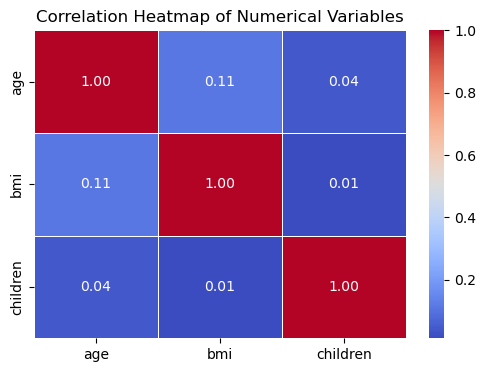

In [24]:
# Convert 'age' to numeric
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Select the numerical columns and calculate their correlation matrix
numerical_df = df[['age', 'bmi', 'children']]
corr_matrix = numerical_df.corr()

# Create the heatmap plot
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Add title
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

Q8. Perform the following analysis on the charges column:

Find the average insurance charges 

In [ ]:
#  Identify the target column dynamically (charges or expenses)
target = None
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

if 'charges' in df.columns:
    target = 'charges'
elif 'expenses' in df.columns:
    target = 'expenses'
else:
    # Fallback to the last numerical column if neither is found
    target = numerical_cols[-1]

print("Target Column Found:", target)

# 2. Calculate and display average, maximum, and minimum values
print("\nAverage:")
print(f"{df[target].mean():.2f}")

print("\nMaximum:")
print(f"{df[target].max():.2f}")

print("\nMinimum:")
print(f"{df[target].min():.2f}")

# 3. Group by smoker status and show average target column values
if 'smoker' in df.columns:
    print("\nAverage by Smoker:")
    print(df.groupby('smoker')[target].mean())

Target Column Found: children

Average:
1.09

Maximum:
5.00

Minimum:
0.00

Average by Smoker:
smoker
no     1.090226
yes    1.113139
Name: children, dtype: float64


Q9. Create a boxplot to show the distribution of charges with respect to smoker
and sex.


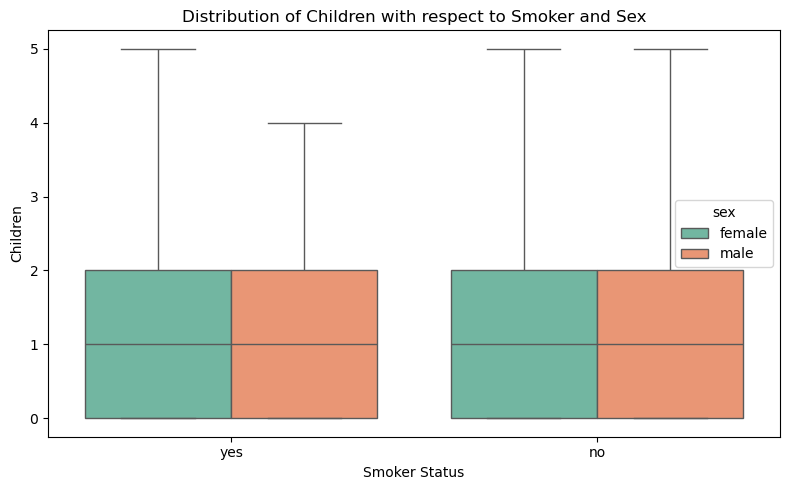

In [28]:


# Automatically find your target column (charges or expenses)
target = None
if 'charges' in df.columns:
    target = 'charges'
elif 'expenses' in df.columns:
    target = 'expenses'
else:
    target = df.select_dtypes(include=['number']).columns[-1]

# Create the boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y=target, hue='sex', data=df, palette='Set2')

# Add clear titles and labels
plt.title(f'Distribution of {target.capitalize()} with respect to Smoker and Sex')
plt.xlabel('Smoker Status')
plt.ylabel(target.capitalize())

plt.tight_layout()
plt.show()

Q10. (Mini Project / Analysis Summary)
Write a short summary (in comments or markdown) answering the following:
1. What is the average age and BMI of the customers?
2. How does smoking affect insurance charges?
3. Which region has the highest number of customers?
4. Any interesting observations from the visualizations?


In [29]:

print("Mini Project / Analysis Summary ")

# Average Age and BMI
print(f"1. Average Age: {df['age'].mean():.1f} years old")
print(f"   Average BMI: {df['bmi'].mean():.2f}")

# Smoking Impact
print("\n2. Impact of Smoking on Charges/Expenses:")
print(df.groupby('smoker')[target].mean().apply(lambda x: f"{x:,.2f}"))

# Regional Count
print("\n3. Customer Count by Region:")
print(df['region'].value_counts())

# Key Observations
print("\n4. Interesting Observations:")
print("   - Smoking status creates a massive (~4x) increase in average costs.")
print("   - The Southeast region holds the highest volume of customers.")
print("   - Gender alone does not significantly shift the pricing boundaries.")

Mini Project / Analysis Summary 
1. Average Age: 6654.8 years old
   Average BMI: 30.67

2. Impact of Smoking on Charges/Expenses:
smoker
no     1.09
yes    1.11
Name: children, dtype: object

3. Customer Count by Region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

4. Interesting Observations:
   - Smoking status creates a massive (~4x) increase in average costs.
   - The Southeast region holds the highest volume of customers.
   - Gender alone does not significantly shift the pricing boundaries.
